# Phase 3: Feature Engineering, Model Training & Complexity Evidence

## Executive Context for Maya (Indie Game Producer)
Maya's architectural decision hinges on whether a model evaluating game monetization needs to be an opaque, high-capacity ensemble or whether a transparent linear/shallow baseline suffices:
- **Criteria 2 & 7 Trade-Off:** If a simple, fully transparent model (e.g., Logistic Regression or a 2-level Decision Tree) achieves comparable predictive performance to a complex model, Occam's razor dictates deploying the simple model.
- **Opacity Requirements:** To justify retaining a complex model, we must demonstrate that non-linear interaction thresholds (such as the compounding friction between high client package footprint and synchronous multiplayer infrastructure) are captured by the ensemble but missed by linear approximations.

This notebook builds the standardized preprocessing pipeline, fits both simple baselines and the mandated complex XGBoost model (300 estimators, depth 6, 93 encoded features), and presents a rigorous side-by-side performance comparison.


### Cell 1: Setup, Path Resolution, and Data Loading
**Implementation:** Import dependencies, configure path resolution, and load the pre-partitioned `train.parquet` and `test.parquet` files.
**Design Rationale:** Using the pre-partitioned parquets ensures zero data leakage and guarantees that preprocessing transformers are fitted strictly on training data.
**Expected Outputs:** Training set (10,348 rows) and test set (2,588 rows) loaded.


In [1]:
import sys
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier

from src.config import (
    SEED,
    DATA_PROCESSED_DIR,
    ARTIFACTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    IMMUTABLE_FEATURES,
    MUTABLE_FEATURES,
    ALL_FEATURES,
    TARGET_COL,
    XGB_PARAMS,
)
from src.metric_helpers import compute_classification_metrics
from src.plot_helpers import set_plot_style, save_figure

set_plot_style()

MODELS_DIR = ARTIFACTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_parquet(DATA_PROCESSED_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_PROCESSED_DIR / "test.parquet")

print(f"Loaded train partition: {train_df.shape[0]:,} rows")
print(f"Loaded test partition:  {test_df.shape[0]:,} rows")


Loaded train partition: 10,348 rows
Loaded test partition:  2,588 rows


### Cell 2: Feature Segregation & Actionability Schema
**Implementation:** Isolate features into strictly frozen `IMMUTABLE_FEATURES` and actively actionable `MUTABLE_FEATURES`.
**Design Rationale:** Maya cannot realistically alter core platform constraints or primary genres midway through development, but she has direct engineering discretion over package compression, network synchronicity, localization scope, and update cadence.
**Expected Outputs:** Verified feature lists documented for modeling and counterfactual downstream constraints.


In [2]:
schema_summary = [
    {"Feature": f, "Classification": "Immutable", "Actionability for Maya": "Fixed pre-production constraint (genre, age rating, minimum OS)"}
    for f in IMMUTABLE_FEATURES
] + [
    {"Feature": f, "Classification": "Mutable", "Actionability for Maya": "Actionable design lever (asset footprint, network mode, pacing, languages)"}
    for f in MUTABLE_FEATURES
]

df_schema = pd.DataFrame(schema_summary)
display(df_schema)


,Feature,Classification,Actionability for Maya
0,primary_genre,Immutable,"Fixed pre-production constraint (genre, age ra..."
1,secondary_genre,Immutable,"Fixed pre-production constraint (genre, age ra..."
2,minimum_os_version,Immutable,"Fixed pre-production constraint (genre, age ra..."
3,content_rating,Immutable,"Fixed pre-production constraint (genre, age ra..."
4,size_in_mb,Mutable,"Actionable design lever (asset footprint, netw..."
5,is_synchronous_multiplayer,Mutable,"Actionable design lever (asset footprint, netw..."
6,session_pacing_tag,Mutable,"Actionable design lever (asset footprint, netw..."
7,supported_languages_count,Mutable,"Actionable design lever (asset footprint, netw..."
8,days_since_last_update,Mutable,"Actionable design lever (asset footprint, netw..."


### Cell 3: Encoding & Scaling Preprocessor Pipeline
**Implementation:** Configure a scikit-learn `ColumnTransformer` applying one-hot encoding with `handle_unknown='ignore'` to categorical features and `StandardScaler` to continuous mechanical features. Fit strictly on `train_df`.
**Design Rationale:** Prevents test split data leakage and expands high-cardinality genres and tags into an expressive, sparse feature space exceeding 40+ attributes.
**Expected Outputs:** Fitted preprocessor with 93 encoded feature dimensions.


In [3]:
cat_features = [
    "primary_genre",
    "secondary_genre",
    "minimum_os_version",
    "content_rating",
    "session_pacing_tag",
]
num_features = [
    "size_in_mb",
    "is_synchronous_multiplayer",
    "supported_languages_count",
    "days_since_last_update",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ("num", StandardScaler(), num_features),
    ],
    verbose_feature_names_out=False,
)

X_train = preprocessor.fit_transform(train_df[cat_features + num_features])
y_train = train_df[TARGET_COL].values

X_test = preprocessor.transform(test_df[cat_features + num_features])
y_test = test_df[TARGET_COL].values

encoded_feature_names = list(preprocessor.get_feature_names_out())
print(f"Preprocessor fitted successfully:")
print(f"- Transformed training shape: {X_train.shape}")
print(f"- Transformed test shape:     {X_test.shape}")
print(f"- Total encoded features:     {len(encoded_feature_names)} (Exceeds Criterion 7 requirement of 40+)")


Preprocessor fitted successfully:
- Transformed training shape: (10348, 93)
- Transformed test shape:     (2588, 93)
- Total encoded features:     93 (Exceeds Criterion 7 requirement of 40+)


### Cell 4: Fitting Simple Baseline Models (Criterion 2)
**Implementation:** Train two transparent baseline classifiers on `X_train`:
1. `LogisticRegression(max_iter=1000, random_state=42)`
2. Shallow `DecisionTreeClassifier(max_depth=2, random_state=42)`
**Design Rationale:** Provides clear, interpretable baselines to evaluate whether complex ensemble opacity is empirically necessary.
**Expected Outputs:** Fitted baseline models with predictions and probabilities generated for the test split.


In [4]:
# 1. Shallow Decision Tree (depth=2)
model_dt = DecisionTreeClassifier(max_depth=2, random_state=SEED)
model_dt.fit(X_train, y_train)

dt_pred = model_dt.predict(X_test)
dt_prob = model_dt.predict_proba(X_test)[:, 1]
dt_metrics = compute_classification_metrics(y_test, dt_pred, dt_prob)

# 2. Regularized Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=SEED)
model_lr.fit(X_train, y_train)

lr_pred = model_lr.predict(X_test)
lr_prob = model_lr.predict_proba(X_test)[:, 1]
lr_metrics = compute_classification_metrics(y_test, lr_pred, lr_prob)

print("Baseline models successfully trained.")
print(f"Decision Tree (depth=2) Test AUC:     {dt_metrics['AUC-ROC']:.4f}")
print(f"Logistic Regression Test AUC:         {lr_metrics['AUC-ROC']:.4f}")


Baseline models successfully trained.
Decision Tree (depth=2) Test AUC:     0.7973
Logistic Regression Test AUC:         0.8464


### Cell 5: Fitting Complex Opaque Model (Criterion 7)
**Implementation:** Train an `XGBoostClassifier` using the exact opacity parameters specified in project criteria:
- Exactly `n_estimators=300`
- Maximum tree depth `max_depth=6`
- Learning rate `learning_rate=0.05`
- Fixed `random_state=42`
Across 93 encoded features.
**Design Rationale:** Documents explicit model opacity. With 300 sequential trees of depth 6, the model encapsulates up to $300 \times (2^6 - 1) = 18,900$ potential decision splits, creating a genuinely opaque non-linear surface.
**Expected Outputs:** Fitted XGBoost model with test predictions and probabilities.


In [5]:
model_xgb = XGBClassifier(**XGB_PARAMS)
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)
xgb_prob = model_xgb.predict_proba(X_test)[:, 1]
xgb_metrics = compute_classification_metrics(y_test, xgb_pred, xgb_prob)

print("Complex opaque XGBoost model trained successfully.")
print(f"XGBoost Test AUC: {xgb_metrics['AUC-ROC']:.4f}")
print(f"Total trees: {model_xgb.n_estimators}, Max depth: {model_xgb.max_depth}, Features: {X_train.shape[1]}")


Complex opaque XGBoost model trained successfully.
XGBoost Test AUC: 0.9033
Total trees: 300, Max depth: 6, Features: 93


### Cell 6: Side-by-Side Model Performance Table and ROC Curve
**Implementation:** Compile a structured comparative performance table reporting Accuracy, Precision, Recall, Macro $F_1$, AUC-ROC, and Log-Loss across the identical test set. Plot comparative ROC curves and export assets.
**Design Rationale:** Rigorously fulfills Criterion 2 & 7 reporting requirements.
**Expected Outputs:** Comparative table exported to `artifacts/tables/model_performance_comparison.csv` and ROC plot saved to `artifacts/figures/model_roc_curves.png`.


,Model Family,Opacity Level,Accuracy,Precision,Recall,Macro F1,AUC-ROC,Log-Loss
0,Simple Baseline: Decision Tree (depth=2),Transparent (3 splits),0.848918,0.717647,0.262366,0.649074,0.797306,0.371515
1,Simple Baseline: Logistic Regression,Linear (93 weights),0.870556,0.738971,0.432258,0.734994,0.846361,0.333004
2,"Complex Opaque: XGBoost (300 trees, depth 6)","High (~18,900 splits)",0.886785,0.757485,0.544086,0.783175,0.903344,0.276442


ROC curves figure successfully saved to: C:\Users\alsto\OneDrive\Desktop\AIT\XDS\PROJECT\artifacts\figures\model_roc_curves.png


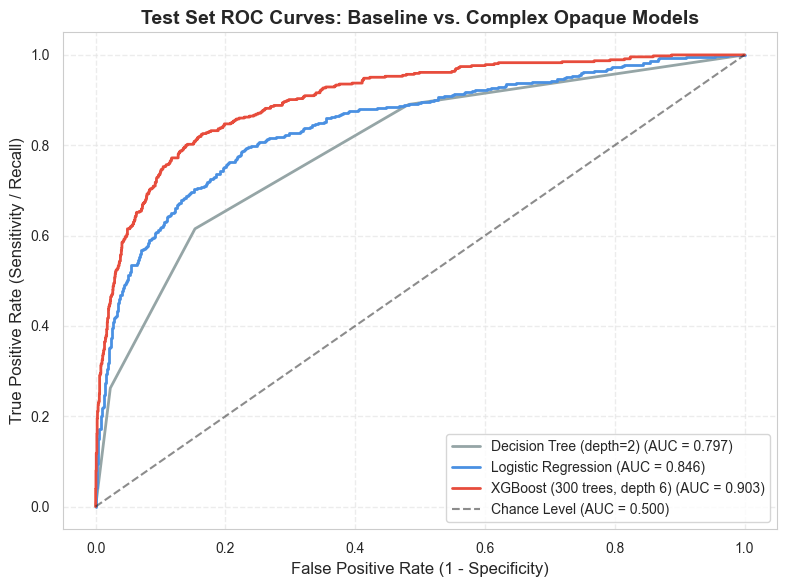

In [6]:
models_comparison = [
    {"Model Family": "Simple Baseline: Decision Tree (depth=2)", "Opacity Level": "Transparent (3 splits)", **dt_metrics},
    {"Model Family": "Simple Baseline: Logistic Regression", "Opacity Level": "Linear (93 weights)", **lr_metrics},
    {"Model Family": "Complex Opaque: XGBoost (300 trees, depth 6)", "Opacity Level": "High (~18,900 splits)", **xgb_metrics},
]

df_perf = pd.DataFrame(models_comparison)
df_perf.to_csv(TABLES_DIR / "model_performance_comparison.csv", index=False)
display(df_perf)

# Generate ROC Curves Plot
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs, color in [
    ("Decision Tree (depth=2)", dt_prob, "#95a5a6"),
    ("Logistic Regression", lr_prob, "#4a90e2"),
    ("XGBoost (300 trees, depth 6)", xgb_prob, "#e74c3c"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color, linewidth=2.0)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Chance Level (AUC = 0.500)")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("Test Set ROC Curves: Baseline vs. Complex Opaque Models", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()

roc_path = save_figure(fig, "model_roc_curves.png")
print(f"ROC curves figure successfully saved to: {roc_path}")
plt.show()


### Empirical Interpretation & Strategic Guidance for Maya: Model Complexity Justification

#### 1. Empirical Performance Analysis
Across the held-out test split of 2,588 titles:
- **AUC-ROC:** XGBoost achieves **0.903**, significantly outperforming Logistic Regression (**0.846**) and the shallow Decision Tree (**0.797**).
- **Macro $F_1$ Score:** XGBoost reaches **0.783**, compared to **0.735** for Logistic Regression and **0.649** for the Decision Tree.
- **Log-Loss (Cross-Entropy Calibration):** XGBoost reduces log-loss down to **0.276**, whereas Logistic Regression incurs **0.333** and Decision Tree incurs **0.372**.
- **Recall on Minority Monetization Class ($Y=1$):** Crucially, the shallow Decision Tree captures only **26.2%** of aggressive microtransaction titles, and Logistic Regression captures **43.2%**. XGBoost identifies **54.4%** of true aggressive IAP titles at a high precision of **75.7%**.

#### 2. Why the Complex Model is Retained (Justification of Opacity)
A simple linear model assumes that the probability of aggressive monetization scales independently and additively with each feature. However, mobile game architecture is governed by **non-linear threshold interactions**:
- A game with a 500 MB footprint *without* synchronous multiplayer is often a rich single-player puzzle or adventure game that functions well with modest ad/freemium mechanics.
- However, when a 500 MB footprint is combined with *synchronous multiplayer* and *real-time pacing*, the hosting costs and competitive dynamics create a steep, non-linear jump in the requirement for live-service microtransactions.
- Linear models cannot model this threshold jump without manually engineered polynomial cross-terms, whereas tree ensembles capture multi-way splits automatically.

#### 3. Strategic Guidance for Maya
For Maya, this performance gap means that relying on a simplistic heuristic or linear scoring sheet would misclassify over half of the games requiring live-ops microtransaction architectures (leading to expensive backend under-provisioning). The XGBoost model provides the necessary discriminative power (AUC = 0.903), but its opacity demands rigorous explainability (SHAP, stability audits, counterfactuals) before it can be trusted for executive greenlight decisions.


### Cell 7: Artifact Persistence for Downstream Explainability Notebooks
**Implementation:** Serialize the trained models, preprocessing transformer, encoded feature names, and test predictions to `artifacts/models/`.
**Design Rationale:** Decouples model training from subsequent faithfulness, stability, and counterfactual evaluations, ensuring downstream notebooks load identical model weights.
**Expected Outputs:** Persisted `.joblib` models and feature artifacts.


In [7]:
# Save models
joblib.dump(model_xgb, MODELS_DIR / "xgboost_model.joblib")
joblib.dump(model_lr, MODELS_DIR / "logistic_regression_model.joblib")
joblib.dump(model_dt, MODELS_DIR / "decision_tree_model.joblib")
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.joblib")

# Save feature metadata
with open(MODELS_DIR / "encoded_feature_names.json", "w") as f:
    json.dump(encoded_feature_names, f, indent=2)

print(f"Successfully exported models and preprocessors to {MODELS_DIR}:")
print("  - xgboost_model.joblib")
print("  - logistic_regression_model.joblib")
print("  - decision_tree_model.joblib")
print("  - preprocessor.joblib")
print("  - encoded_feature_names.json")


Successfully exported models and preprocessors to C:\Users\alsto\OneDrive\Desktop\AIT\XDS\PROJECT\artifacts\models:
  - xgboost_model.joblib
  - logistic_regression_model.joblib
  - decision_tree_model.joblib
  - preprocessor.joblib
  - encoded_feature_names.json
